In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Ручная загрузка файла
uploaded = files.upload()

# Читаем файл (название должно совпадать с загруженным)
df = pd.read_csv('bank.csv')
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()

Saving bank.csv to bank.csv
Размер датасета: 11162 строк, 17 столбцов


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
# 2. Паспорт датасета
print("Список признаков и типы данных:")
print(df.dtypes)

# Описание признаков (гипотезы по названиям [cite: 65])
# age: возраст клиента (int64)
# job: тип занятости (category/object)
# marital: семейное положение (category)
# education: уровень образования (category)
# balance: средний годовой баланс (int64)
# deposit: подписка на депозит (target)

Список признаков и типы данных:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object


Количество полных дубликатов: 0
                age       balance           day      duration      campaign  \
count  11162.000000  11162.000000  11162.000000  11162.000000  11162.000000   
mean      41.231948   1528.538524     15.658036    371.993818      2.508421   
std       11.913369   3225.413326      8.420740    347.128386      2.722077   
min       18.000000  -6847.000000      1.000000      2.000000      1.000000   
25%       32.000000    122.000000      8.000000    138.000000      1.000000   
50%       39.000000    550.000000     15.000000    255.000000      2.000000   
75%       49.000000   1708.000000     22.000000    496.000000      3.000000   
max       95.000000  81204.000000     31.000000   3881.000000     63.000000   

              pdays      previous  
count  11162.000000  11162.000000  
mean      51.330407      0.832557  
std      108.758282      2.292007  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75% 

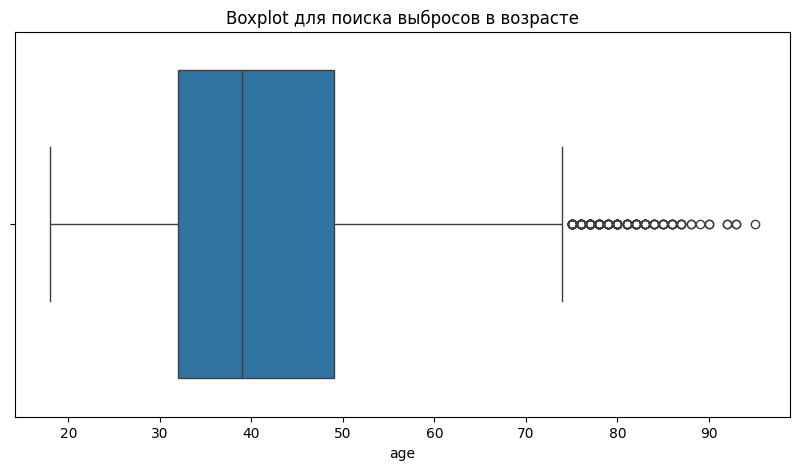

In [4]:
# Проверка дубликатов [cite: 82]
print(f"Количество полных дубликатов: {df.duplicated().sum()}")

# Статистика числовых признаков [cite: 86]
print(df.describe())

# Поиск выбросов для 'age' методом IQR [cite: 93]
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]
print(f"Найдено выбросов в 'age': {len(outliers)} [cite: 95]")

# Визуализация выбросов [cite: 96]
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['age'])
plt.title('Boxplot для поиска выбросов в возрасте')
plt.show()

/tmp/ipython-input-2422413023.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='deposit', data=df, palette='viridis')
/tmp/ipython-input-2422413023.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='deposit', y='age', data=df, palette='Set2')


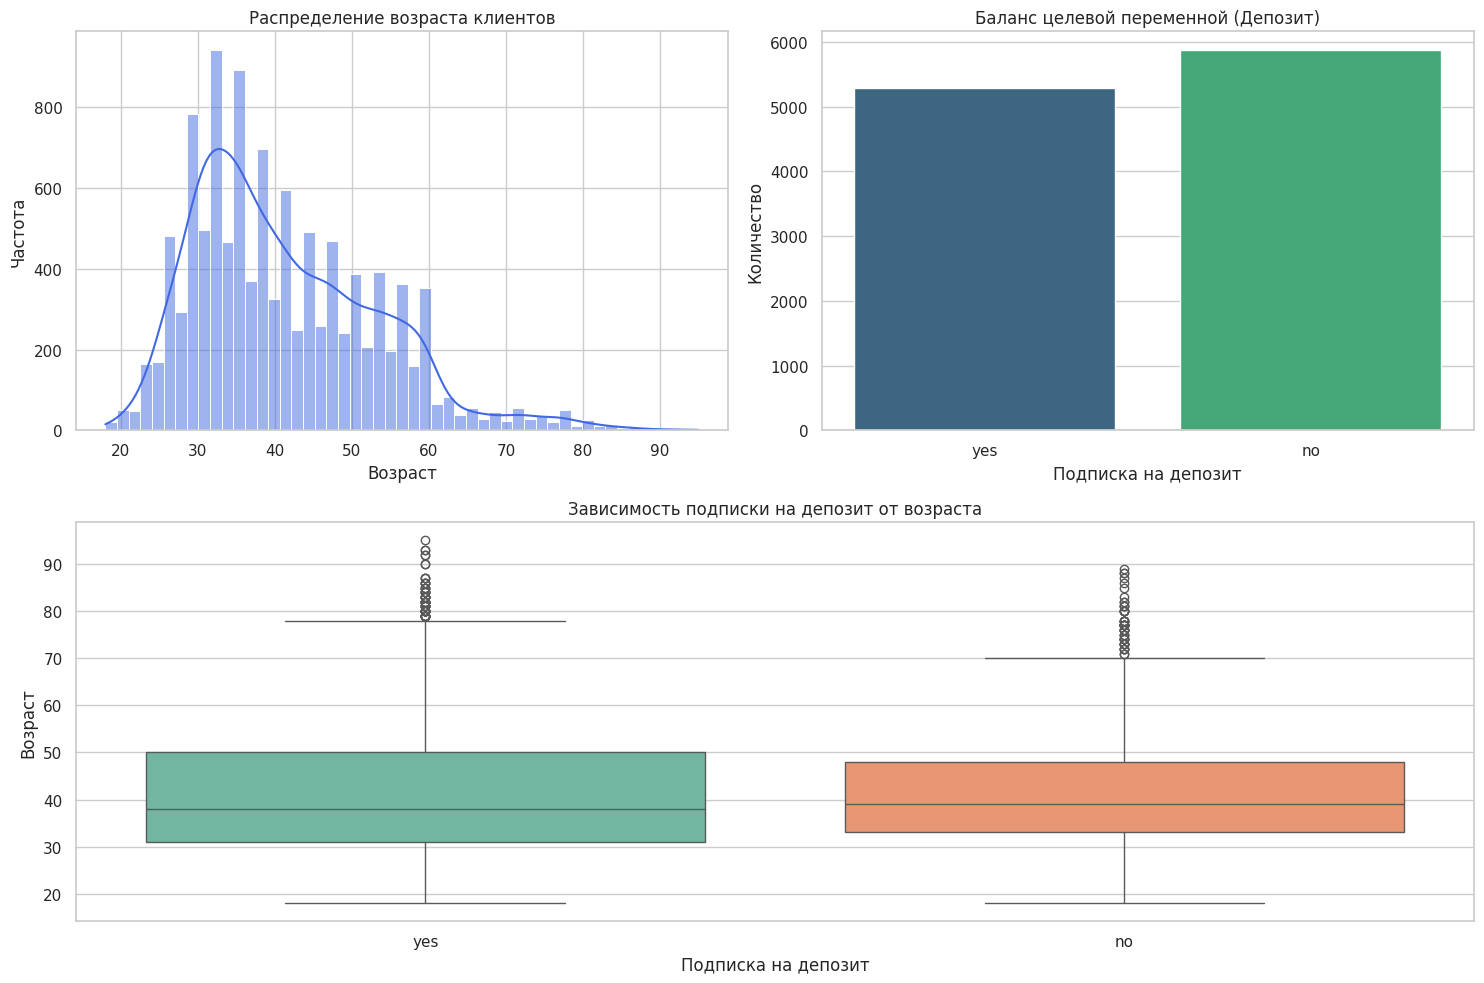

In [5]:
# 4. Разведочный анализ (EDA)
import seaborn as sns
import matplotlib.pyplot as plt

# Настройка стиля графиков
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

# 4.1. Распределение ключевого числового признака (Возраст)
plt.subplot(2, 2, 1)
sns.histplot(df['age'], kde=True, color='royalblue')
plt.title('Распределение возраста клиентов')
plt.xlabel('Возраст')
plt.ylabel('Частота')

# 4.2. Распределение категориального признака (Результат кампании)
plt.subplot(2, 2, 2)
sns.countplot(x='deposit', data=df, palette='viridis')
plt.title('Баланс целевой переменной (Депозит)')
plt.xlabel('Подписка на депозит')
plt.ylabel('Количество')

# 4.3. Визуализация зависимости (Возраст vs Депозит)
plt.subplot(2, 1, 2)
sns.boxplot(x='deposit', y='age', data=df, palette='Set2')
plt.title('Зависимость подписки на депозит от возраста')
plt.xlabel('Подписка на депозит')
plt.ylabel('Возраст')

plt.tight_layout()
plt.show()

# Комментарии к графикам (согласно пункту 4.3 задания):
# 1. Возраст: Большинство клиентов находятся в диапазоне 30-50 лет. Распределение имеет правостороннюю асимметрию.
# 2. Депозит: Классы распределены относительно равномерно, что хорошо для будущего обучения моделей.
# 3. Зависимость: Заметно, что более молодые и более пожилые люди чаще соглашаются на депозит, тогда как средний возраст более консервативен.